# T4 · Relativity — where the law is an approximation

Gravity's law was exact. This one is a **series**, and you get to choose where
to stop:

$$\dot f = \frac{96}{5}\pi^{8/3}\left(\frac{G\mathcal{M}}{c^3}\right)^{5/3} f^{11/3}
\left[1 + \text{(1PN)} + \text{(1.5PN tail)} + \text{(2PN)} + \cdots\right]$$

Truncating early does not give you a wrong-looking fit. It gives you a
**confident wrong answer**, which is far more dangerous.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, torch, matplotlib.pyplot as plt
from physprior.viz import plots as P
P.use_style()
torch.set_default_dtype(torch.float64)
print("torch", torch.__version__)

from physprior.io import load_json
meta = load_json("relativity/gw150914", "meta")
print(f"GW150914: {meta['n_cycles']} usable cycles, SNR {meta['snr']}")
print(f"published chirp mass (detector frame): {meta['published_Mc_detector']:.3f} Msun")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


torch 2.11.0


GW150914: 6 usable cycles, SNR [3.47426881592833, 3.928590789088904, 3.763167027553813, 4.4957603710361145, 5.998463770953741, 7.775849308920623]
published chirp mass (detector frame): 31.174 Msun


## The control: a simulation where GR is exactly what was put in

`d2u/dphi2 + u = GM/h^2 + (3GM/c^2)u^2`, integrated with the GR term on and
off. The difference between the two runs is the precession, and it comes out
at 42.98 arcsec/century -- the measured value.

In [2]:
from IPython.display import HTML, display
display(HTML('<img src="../../figures/relativity/schwarzschild_precession.gif" width="560">'))

Locating the perihelion here is **root-finding, not parabola-fitting**. The
shift is 5e-7 rad per orbit and fitting a parabola to a sampled grid is good
to ~1e-6 -- bigger than the effect. The first version of this simulation duly
reported a Newtonian "precession" 20% larger than the GR one.

## The post-Newtonian ablation

The same data, the same code, the same fitting — only the order at which the
expansion is truncated changes.

In [3]:
import pandas as pd
abl = pd.DataFrame(meta["pn_ablation"])
print(abl[["label", "Mc", "Mc_sigma", "bias_Msun", "bias_sigma", "rmse_hz", "converged"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4g}"))

          label    Mc  Mc_sigma  bias_Msun  bias_sigma  rmse_hz  converged
0PN (Newtonian) 40.07     4.057      8.901       2.194    4.087       True
            1PN   200     710.2      168.8      0.2377    114.3      False
  1.5PN (+tail) 31.97      2.78     0.7916      0.2847     4.23       True
            2PN 30.75     2.635    -0.4193     -0.1591    4.254       True


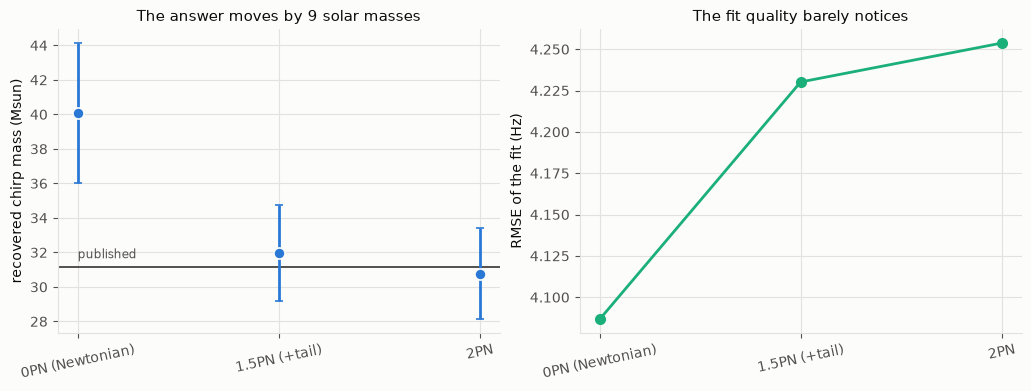

chirp mass spread across orders: 9.32 Msun
RMSE spread across orders:       0.167 Hz


In [4]:
# The 1PN row is EXCLUDED because its fit pinned to a bound: a parameter at
# its bound has not converged, whatever the optimiser reports, and plotting
# it as a point would imply a measurement that was never made.
ok = abl[abl.converged]
x = np.arange(len(ok))
fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.8))
axes[0].axhline(meta["published_Mc_detector"], color=P.INK_2, lw=1.4)
axes[0].annotate("published", xy=(x[0], meta["published_Mc_detector"]),
                 xytext=(0, 6), textcoords="offset points",
                 color=P.INK_2, fontsize=8.5)
axes[0].errorbar(x, ok.Mc, yerr=ok.Mc_sigma, fmt="o",
                 color=P.ARM_COLOR["physics"], capsize=3, markersize=8,
                 markeredgecolor=P.SURFACE, markeredgewidth=1.2)
axes[0].set_xticks(x, ok.label, rotation=12)
axes[0].set_ylabel("recovered chirp mass (Msun)")
axes[0].set_title("The answer moves by 9 solar masses")
axes[1].plot(x, ok.rmse_hz, "-o", color=P.ARM_COLOR["pinn"])
axes[1].set_xticks(x, ok.label, rotation=12)
axes[1].set_ylabel("RMSE of the fit (Hz)")
axes[1].set_title("The fit quality barely notices")
plt.show()
print(f"chirp mass spread across orders: {ok.Mc.max() - ok.Mc.min():.2f} Msun")
print(f"RMSE spread across orders:       {ok.rmse_hz.max() - ok.rmse_hz.min():.3f} Hz")

## The finding: goodness of fit does not diagnose a wrong law

Note the row that is **missing from the plot**. The 1PN fit pinned its
parameter to a bound at `Mc = 200` with a formal error of 710 — the optimiser
reported a result, and it is not one. This project's rule is that a parameter
at its bound has not converged whatever the optimiser says, so it is marked
and excluded rather than drawn as a point.

At Newtonian order the recovered chirp mass is biased by about **+9 M☉** with
a formal error of 4.1 — the fit reports high confidence in a wrong number.
Adding the 1.5PN tail and 2PN terms removes the bias **while the RMSE hardly
moves**.

If you are ever tempted to choose a physical model by held-out error, this is
the counter-example. The residual is dominated by measurement noise, not by
the missing physics, so it cannot see the missing physics.

## This track's PINN is a different animal

Because the law here *is* a differential equation, `relativity/gw150914` uses
the **residual PINN of Raissi et al. (2019)** — the T1 form — rather than the
law-plus-correction form of T3:

```python
y  = net(t_collocation)
dy = torch.autograd.grad(y, t_collocation, create_graph=True)[0]
residual = dy - fdot_pn(y, Mc)          # Mc is an nn.Parameter
loss = data_mse + w_phys * (residual ** 2).mean()
```

`create_graph=True` is what lets the residual itself be differentiated during
back-propagation, so `Mc` receives a gradient *through the physics term*.
That single flag is the difference between training the constant and not.

## And a warning that has nothing to do with networks

The chirp mass is extracted through a chain of signal-processing choices. One
— the envelope SNR a cycle must clear — was set to 2.0 a priori and looked
perfectly reasonable. Injecting a **known** chirp mass into the **real
detector noise** and running the identical code:

In [5]:
from physprior.io import load_table
cal = load_table("relativity", "threshold_calibration")
print(cal.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

 snr_threshold  n_seeds  n_usable  n_failed  median_cycles  median_Mc  bias_pct  scatter_Msun  frac_within_20pct
             2       10        10         0             10      9.316    -70.12          5.55                  0
           2.5       10        10         0              7       29.4    -5.685         10.91                0.6
             3       10        10         0              5       30.9   -0.8708         3.013                0.9
           3.5       10         5         5              5      33.16     6.377         2.711                  1
             4       10         0        10            NaN        NaN       NaN           NaN                  0


At a threshold of 2.0 the pipeline recovers 9.3 M☉ for an injected 31.2 — a
**−70% bias**. The cut was re-chosen on injections, never on the real event.

> A pipeline you have not injected into has no error budget, and a constant it
> returns is a number with no uncertainty attached to the method that produced
> it.

See [`docs/relativity/`](../../docs/relativity). Next:
[T5](T5_quantum_wavefunction.ipynb), where there is no data at all.